# Clustering Espacial de Altiplanos (v2) — Comparación de vecindades (KNN vs. radio de distancia)

## Introducción

**Qué se busca:** en `01_clustering_altiplanos_v2.ipynb` se tipificaron los 491 altiplanos
usando solo sus atributos morfométricos (K-means / Ward), sin ninguna noción de cercanía
geográfica entre ellos. Aquí se pone a prueba una idea distinta: ¿cambia (o mejora) la
tipología si, además de ser morfométricamente parecidos, se exige que dos altiplanos estén
geográficamente cerca para poder quedar en el mismo grupo? Este notebook sigue siendo el
cluster **de altiplanos** (busca comprender cómo se agrupan estas superficies según sus
características, ahora añadiendo una restricción de cercanía) — no debe confundirse con el
cluster **de píxeles** de `Clustering_Regiones_v2.ipynb`, que construye una zonificación
completamente distinta con otro propósito (agrupar el territorio para el modelo jerárquico).

Como los polígonos NO son contiguos (no comparten borde entre sí), no se puede definir
vecindad con contigüidad tipo Queen/Rook (todos quedarían como "isla", sin vecinos). En su
lugar se define la vecindad a partir de la **distancia entre los centroides** de los
polígonos, de dos formas alternativas:
- **(a) k-vecinos más cercanos (KNN):** cada altiplano se conecta con sus k centroides más
  cercanos, sin importar cuán lejos estén en términos absolutos — por construcción, **nunca
  deja ningún polígono sin vecinos**.
- **(b) radio de distancia fijo (DistanceBand):** cada altiplano se conecta con TODOS los
  centroides que estén dentro de un radio de d metros — puede tener más, menos, o **incluso
  cero vecinos** ("isla") según qué tan aislado esté. Este notebook reporta explícitamente,
  para cada radio candidato, cuántos polígonos quedan sin ningún vecino (ver sección [5]).

**Método del libro utilizado:** notebook `08_ClusterEspacial`, sección de "Agrupamiento
espacial (Regionalización)". El libro compara puntualmente el Silhouette obtenido con una
matriz KNN (k=6) contra una matriz DistanceBand (30 km) para el dataset de cuencas
colombianas. Aquí se generaliza esa comparación puntual a un barrido sistemático de muchos
valores de k y de d.

**Cambios respecto a la versión anterior (`02_clustering_espacial_altiplanos.py`):**
convertido a `.ipynb` real; se agregó exploración de datos (histograma de distancias al
vecino más cercano); el reporte de polígonos sin vecinos en DistanceBand (antes una columna
más de una tabla) ahora tiene su propia sección con tabla y gráfico dedicados; y el número
de clusters de referencia (`K_ELEGIDO`) y la búsqueda del "mejor" (vecindad, n_clusters) ya
NO permiten k=2/k=3, consolidando aquí el criterio de `06_mapas_clusters_n_mayor_3.py` en
vez de mantenerlo como script de corrección aparte; **se retiró el índice de
Calinski-Harabasz** (no es parte del método del libro, ver `01_clustering_altiplanos_v2.ipynb`);
y los radios candidatos de `DistanceBand` ahora se redondean a múltiplos de 0.5 km (máximo
un decimal) en vez de a percentiles con decimales arbitrarios, para que las tablas y ejes de
los gráficos muestren valores limpios.


## [0] Configuración: rutas, semilla y carpeta de resultados de este notebook


In [1]:
import struct
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial import cKDTree
from scipy.sparse.csgraph import connected_components
from scipy.spatial.distance import pdist, squareform

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

from libpysal.weights import KNN, DistanceBand

RUTA_SHP = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas\Estadisticas_Cluster.shp"
RUTA_DBF = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas\Estadisticas_Cluster.dbf"
CARPETA_RESULTADOS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados"
CARPETA_FIGURAS = os.path.join(CARPETA_RESULTADOS, "02_clustering_espacial_altiplanos_v2")
os.makedirs(CARPETA_FIGURAS, exist_ok=True)

SEMILLA = 42
N_CLUSTERS_MINIMO = 4  # se descartan k=2 y k=3 en toda busqueda de "mejor" configuracion (ver 01_v2)

print(f"Carpeta de figuras de este notebook: {CARPETA_FIGURAS}")


Carpeta de figuras de este notebook: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\02_clustering_espacial_altiplanos_v2


## [1] Utilidad: corrección de codificación del `.dbf` (idéntica a `01_clustering_altiplanos_v2.ipynb`)


In [2]:
def nombres_reales_columnas_dbf(ruta_dbf: str, encoding: str = "utf-8") -> list[str]:
    with open(ruta_dbf, "rb") as f:
        encabezado = f.read(32)
        tam_encabezado = struct.unpack("<H", encabezado[8:10])[0]
        f.seek(0)
        encabezado_completo = f.read(tam_encabezado)

    nombres = []
    offset = 32
    while True:
        descriptor = encabezado_completo[offset:offset + 32]
        if descriptor[0:1] == b"\x0d" or len(descriptor) < 32:
            break
        crudo = descriptor[0:11].split(b"\x00")[0]
        nombres.append(crudo.decode(encoding))
        offset += 32
    return nombres


## [2] Carga de datos y variables de clustering

Mismas 9 variables morfométricas de `01_clustering_altiplanos_v2.ipynb` (medias y
desviaciones estándar de altitud, relieve y pendiente, más los percentiles de altitud), con
la misma estandarización. El **Área** queda excluida por instrucción explícita (ver
justificación en `01_clustering_altiplanos_v2.ipynb`, sección [4]).


In [3]:
gdf = gpd.read_file(RUTA_SHP)
gdf.columns = nombres_reales_columnas_dbf(RUTA_DBF) + ["geometry"]

variables_cluster = [
    "Altitud_X", "Altitud_St", "Alt_90", "Alt_50", "Alt_10",
    "Relieve_X", "Relieve_St", "Pend_X", "Pend_St",
]

escalador = StandardScaler()
X = escalador.fit_transform(gdf[variables_cluster])

print(f"Poligonos cargados: {len(gdf)}")
print(f"Variables de clustering (sin Area): {variables_cluster}")


Poligonos cargados: 491
Variables de clustering (sin Area): ['Altitud_X', 'Altitud_St', 'Alt_90', 'Alt_50', 'Alt_10', 'Relieve_X', 'Relieve_St', 'Pend_X', 'Pend_St']


## [3] Exploración de datos: distancia entre centroides vecinos

**Qué se busca:** antes de "adivinar" un radio de distancia para DistanceBand, conviene
conocer la escala real de las distancias entre los altiplanos. Se calcula, para cada
polígono, la distancia a su centroide vecino MÁS cercano (usando un KD-Tree sobre los
centroides). El CRS del shapefile (EPSG:32618) es una proyección plana EN METROS, así que
todo cálculo e insumo que se le pase a `libpysal` (KNN, DistanceBand) se sigue haciendo
internamente en metros; los KILÓMETROS solo se usan para MOSTRAR los resultados.


In [4]:
centroides = gdf.geometry.centroid
coordenadas = np.column_stack([centroides.x, centroides.y])

arbol = cKDTree(coordenadas)
distancias, _ = arbol.query(coordenadas, k=2)  # k=2: el vecino "0" es el mismo punto (dist=0)
distancia_vecino_mas_cercano = distancias[:, 1]

print("N = 491 poligonos (todos con al menos un vecino en la grilla completa, por construccion del KD-Tree)")
print("\nDistancia al centroide vecino mas cercano (km):")
percentiles = [0, 10, 25, 50, 75, 90, 95, 99, 100]
resumen_distancias = np.percentile(distancia_vecino_mas_cercano, percentiles)
for p, valor in zip(percentiles, resumen_distancias):
    print(f"  percentil {p:>3}: {valor / 1000:>8,.2f} km")


N = 491 poligonos (todos con al menos un vecino en la grilla completa, por construccion del KD-Tree)

Distancia al centroide vecino mas cercano (km):
  percentil   0:     0.68 km
  percentil  10:     1.71 km
  percentil  25:     2.63 km
  percentil  50:     3.70 km
  percentil  75:     5.18 km
  percentil  90:     7.36 km
  percentil  95:     9.84 km
  percentil  99:    14.94 km
  percentil 100:    28.07 km


**Histograma de la distancia al vecino más cercano:** muestra qué tan dispersos o
concentrados están los 491 altiplanos entre sí, y anticipa qué radios de `DistanceBand`
dejarán a muchos polígonos aislados (radios menores que la mayoría de las barras de la
izquierda del histograma) frente a radios que conectan casi todo el conjunto.


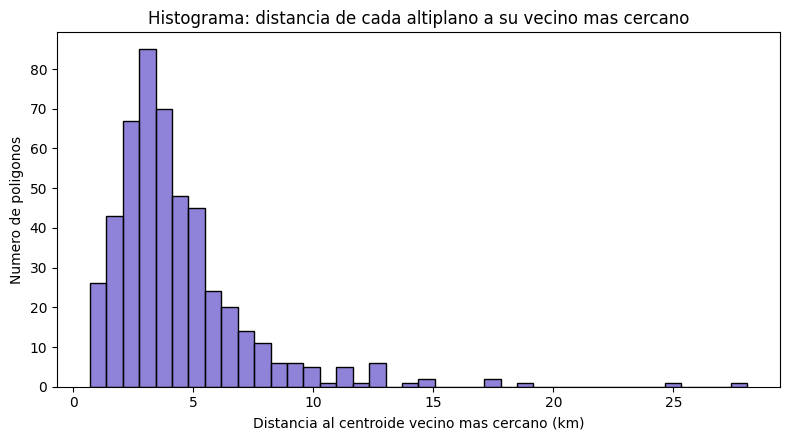

In [5]:
plt.figure(figsize=(8, 4.5))
sns.histplot(distancia_vecino_mas_cercano / 1000, bins=40, color="slateblue")
plt.xlabel("Distancia al centroide vecino mas cercano (km)")
plt.ylabel("Numero de poligonos")
plt.title("Histograma: distancia de cada altiplano a su vecino mas cercano")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "00_histograma_distancia_vecino_cercano.png"), dpi=150)
plt.show()


In [6]:
def redondear_medio_km(valor_m):
    '''Redondea una distancia en metros al medio kilometro mas cercano (multiplos de 0.5
    km: 3.5, 7.0, 12.5...), para que las etiquetas de radio en tablas y graficos sean
    valores limpios en vez de percentiles con decimales arbitrarios (ej. 7.4, 3.7 km).'''
    km_redondeado = round((valor_m / 1000) * 2) / 2
    return max(km_redondeado, 0.5)  # nunca menor a 0.5 km


radios_candidatos_km = sorted(set(
    redondear_medio_km(v) for v in np.percentile(distancia_vecino_mas_cercano, [50, 60, 70, 80, 90, 95, 99, 100])
))
radios_candidatos = [int(round(km * 1000)) for km in radios_candidatos_km]
print(f"Radios candidatos derivados de los datos (km, redondeados a multiplos de 0.5): {radios_candidatos_km}")

vecinos_candidatos = [3, 4, 5, 6, 8, 10, 15, 20, 30, 40]


Radios candidatos derivados de los datos (km, redondeados a multiplos de 0.5): [3.5, 4.0, 5.0, 5.5, 7.5, 10.0, 15.0, 28.0]


## [4] Número de referencia de clusters (K_ELEGIDO)

**Qué se busca:** para las comparaciones de línea base (secciones 5-7) se necesita un único
`K_ELEGIDO` de referencia. Se recalcula aquí con el MISMO criterio consolidado de
`01_clustering_altiplanos_v2.ipynb` (mejor Silhouette con `n_clusters >= 4`), en vez de
depender de haber corrido ese notebook antes — cada notebook de este proyecto es
autocontenido y reproducible por su cuenta.


In [7]:
rango_k_referencia = list(range(2, 51))
siluetas_referencia = []
for k in rango_k_referencia:
    etiquetas_tmp = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10).fit_predict(X)
    siluetas_referencia.append(silhouette_score(X, etiquetas_tmp))

candidatos_validos = [(k, ss) for k, ss in zip(rango_k_referencia, siluetas_referencia) if k >= N_CLUSTERS_MINIMO]
K_ELEGIDO, ss_referencia = max(candidatos_validos, key=lambda par: par[1])
print(f"K_ELEGIDO (mejor SS con n_clusters >= {N_CLUSTERS_MINIMO}): {K_ELEGIDO}  (SS={ss_referencia:.3f})")
print("(debe coincidir con el K_ELEGIDO de 01_clustering_altiplanos_v2.ipynb, que usa el mismo criterio)")


C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

...

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K_ELEGIDO (mejor SS con n_clusters >= 4): 7  (SS=0.284)
(debe coincidir con el K_ELEGIDO de 01_clustering_altiplanos_v2.ipynb, que usa el mismo criterio)


## [5] Línea base: clustering SIN restricción espacial

Se usa el MISMO algoritmo (Ward aglomerativo) y el MISMO `K_ELEGIDO` que se usará con las
restricciones espaciales, pero sin ninguna matriz de conectividad (`connectivity=None`),
para que la única diferencia entre esta corrida y las siguientes sea la restricción de
vecindad, y no el algoritmo en sí.


In [8]:
modelo_base = AgglomerativeClustering(n_clusters=K_ELEGIDO, linkage="ward")
etiquetas_base = modelo_base.fit_predict(X)
silhouette_base = silhouette_score(X, etiquetas_base)

print(f"Silhouette SIN restriccion espacial (linea base, k={K_ELEGIDO}): {silhouette_base:.3f}")


Silhouette SIN restriccion espacial (linea base, k=7): 0.211


## [6] Barrido KNN: Silhouette para cada número de vecinos

Para cada valor de k en `vecinos_candidatos`, se construye la matriz de pesos KNN entre
centroides, se fuerza a que el clustering jerárquico solo pueda fusionar altiplanos
conectados en esa matriz, y se mide el Silhouette resultante.

**Ventajas / desventajas de KNN como definición de vecindad:**
- (+) Todo polígono queda garantizado con exactamente k vecinos → **nunca hay "islas"**
  (polígonos sin ningún vecino), sin importar qué tan disperso sea su entorno.
- (-) En zonas muy dispersas, el k-ésimo vecino más cercano puede estar a decenas o
  cientos de kilómetros, lo cual no es realmente "cercano" en un sentido geográfico.
- (-) La relación de vecindad no es simétrica en general; aquí se simetriza tomando el
  máximo entre la matriz y su transpuesta.


In [9]:
def simetrizar(matriz_dispersa):
    return matriz_dispersa.maximum(matriz_dispersa.T)


resultados_knn = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for k in vecinos_candidatos:
        w_knn = KNN.from_dataframe(gdf, k=k)
        conectividad = simetrizar(w_knn.sparse)
        n_componentes, _ = connected_components(conectividad, directed=False)

        modelo = AgglomerativeClustering(n_clusters=K_ELEGIDO, linkage="ward", connectivity=conectividad)
        etiquetas = modelo.fit_predict(X)
        silueta = silhouette_score(X, etiquetas)

        resultados_knn.append({
            "k_vecinos": k, "silhouette": silueta,
            "n_componentes_conectados": n_componentes,
            "n_poligonos_sin_vecinos": len(w_knn.islands),
        })

resultados_knn = pd.DataFrame(resultados_knn)
print("Resultados KNN (numero de vecinos vs. Silhouette):")
print(resultados_knn)
print(f"\nConfirmacion: KNN nunca deja poligonos sin vecinos "
      f"(n_poligonos_sin_vecinos = {resultados_knn['n_poligonos_sin_vecinos'].unique()} en todos los casos).")


Resultados KNN (numero de vecinos vs. Silhouette):
   k_vecinos  silhouette  n_componentes_conectados  n_poligonos_sin_vecinos
0          3    0.160647                         8                        0
1          4    0.137028                         5                        0
2          5    0.145745                         3                        0
3          6    0.122110                         3                        0
4          8    0.151886                         3                        0
5         10    0.154840                         2                        0
6         15    0.147379                         1                        0
7         20    0.164518                         1                        0
8         30    0.170947                         1                        0
9         40    0.160639                         1                        0

Confirmacion: KNN nunca deja poligonos sin vecinos (n_poligonos_sin_vecinos = [0] en todos los casos).


## [7] Barrido DistanceBand: Silhouette para cada radio — reporte explícito de polígonos sin vecinos

Lo mismo que el paso anterior, pero definiendo la vecindad por un radio fijo en metros en
vez de un número fijo de vecinos.

**Ventajas / desventajas de DistanceBand como definición de vecindad:**
- (+) Tiene una interpretación geográfica directa ("altiplanos a menos de d metros uno del
  otro"), a diferencia de KNN donde k no tiene una lectura física directa.
- (-) Un mismo radio puede dejar a polígonos en zonas dispersas **sin ningún vecino**
  ("islas"). Por instrucción explícita del usuario, esta sección reporta con su propia
  tabla y gráfico cuántos polígonos quedan sin vecinos para CADA radio candidato — no solo
  como una columna más de la tabla general.


In [10]:
resultados_distancia = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for d in radios_candidatos:
        w_dist = DistanceBand.from_dataframe(gdf, threshold=d, binary=True)
        conectividad = simetrizar(w_dist.sparse)
        n_componentes, _ = connected_components(conectividad, directed=False)

        modelo = AgglomerativeClustering(n_clusters=K_ELEGIDO, linkage="ward", connectivity=conectividad)
        etiquetas = modelo.fit_predict(X)
        silueta = silhouette_score(X, etiquetas)

        resultados_distancia.append({
            "radio_m": d,
            "radio_km": round(d / 1000, 1),
            "silhouette": silueta,
            "n_componentes_conectados": n_componentes,
            "n_poligonos_sin_vecinos": len(w_dist.islands),
            "pct_poligonos_sin_vecinos": 100 * len(w_dist.islands) / len(gdf),
        })

resultados_distancia = pd.DataFrame(resultados_distancia)
print("Resultados DistanceBand (radio vs. Silhouette vs. poligonos sin vecinos):")
print(resultados_distancia)


Resultados DistanceBand (radio vs. Silhouette vs. poligonos sin vecinos):
   radio_m  radio_km  silhouette  n_componentes_conectados  \
0     3500       3.5    0.220441                       334   
1     4000       4.0    0.200614                       292   
2     5000       5.0    0.222013                       208   
3     5500       5.5    0.206186                       175   
4     7500       7.5    0.215426                        82   
5    10000      10.0    0.183700                        42   
6    15000      15.0    0.161530                        14   
7    28000      28.0    0.199006                         5   

   n_poligonos_sin_vecinos  pct_poligonos_sin_vecinos  
0                      263                  53.564155  
1                      218                  44.399185  
2                      132                  26.883910  
3                      107                  21.792261  
4                       49                   9.979633  
5                       23     

**Tabla y gráfico dedicados: ¿cuántos altiplanos quedan sin ningún vecino, para cada
radio?** Esta es la pregunta central pedida explícitamente: con radios pequeños, un
porcentaje sustancial de polígonos puede no tener NINGÚN otro altiplano dentro del radio
(quedan como "isla" en el grafo de vecindad), lo cual hace que la restricción de
conectividad para ese radio sea forzada y menos confiable, incluso si su Silhouette
numérico resulta alto.


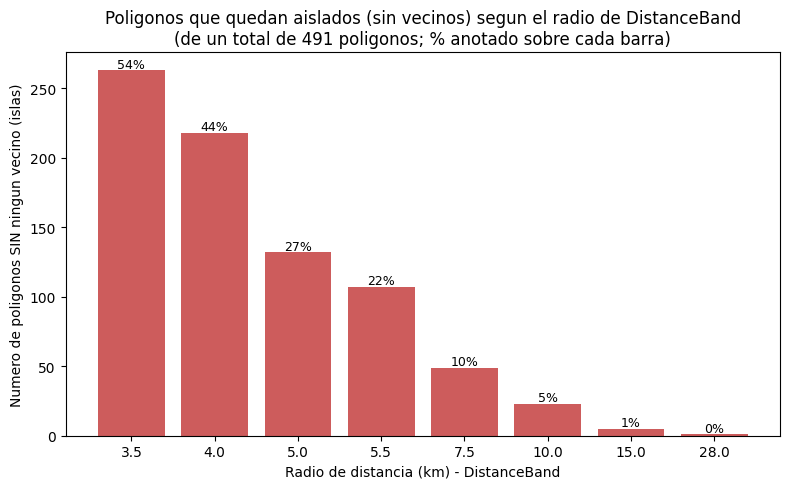

Resumen de poligonos sin vecinos por radio:
 radio_km  n_poligonos_sin_vecinos  pct_poligonos_sin_vecinos
      3.5                      263                  53.564155
      4.0                      218                  44.399185
      5.0                      132                  26.883910
      5.5                      107                  21.792261
      7.5                       49                   9.979633
     10.0                       23                   4.684318
     15.0                        5                   1.018330
     28.0                        1                   0.203666


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(resultados_distancia["radio_km"].astype(str), resultados_distancia["n_poligonos_sin_vecinos"],
                 color="indianred")
for barra, pct in zip(barras, resultados_distancia["pct_poligonos_sin_vecinos"]):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 2,
            f"{pct:.0f}%", ha="center", fontsize=9)
ax.set_xlabel("Radio de distancia (km) - DistanceBand")
ax.set_ylabel("Numero de poligonos SIN ningun vecino (islas)")
ax.set_title("Poligonos que quedan aislados (sin vecinos) segun el radio de DistanceBand\n"
              f"(de un total de {len(gdf)} poligonos; % anotado sobre cada barra)")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "01_poligonos_sin_vecinos_distanceband.png"), dpi=150)
plt.show()

print("Resumen de poligonos sin vecinos por radio:")
print(resultados_distancia[["radio_km", "n_poligonos_sin_vecinos", "pct_poligonos_sin_vecinos"]].to_string(index=False))


## [8] Comparación gráfica: KNN vs. DistanceBand vs. línea base

Se visualiza en un solo par de gráficos cómo varía el Silhouette al cambiar el parámetro de
vecindad, con una línea horizontal de referencia que marca el Silhouette del clustering SIN
restricción espacial (sección [5]).


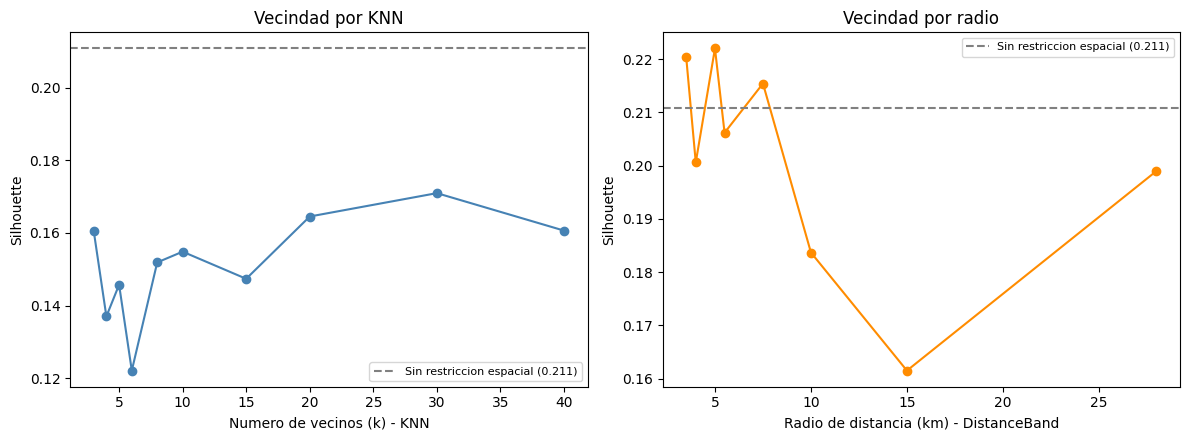

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(resultados_knn["k_vecinos"], resultados_knn["silhouette"], marker="o", color="steelblue")
ax1.axhline(silhouette_base, color="gray", linestyle="--", label=f"Sin restriccion espacial ({silhouette_base:.3f})")
ax1.set_xlabel("Numero de vecinos (k) - KNN"); ax1.set_ylabel("Silhouette"); ax1.set_title("Vecindad por KNN")
ax1.legend(fontsize=8)

ax2.plot(resultados_distancia["radio_km"], resultados_distancia["silhouette"], marker="o", color="darkorange")
ax2.axhline(silhouette_base, color="gray", linestyle="--", label=f"Sin restriccion espacial ({silhouette_base:.3f})")
ax2.set_xlabel("Radio de distancia (km) - DistanceBand"); ax2.set_ylabel("Silhouette"); ax2.set_title("Vecindad por radio")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "02_silhouette_vecindad_espacial.png"), dpi=150)
plt.show()


## [9] Mapas de calor: SS según vecindad (eje Y) y número de clusters (eje X)

**Qué se busca:** las secciones 6-8 fijaron el número de clusters en `K_ELEGIDO` y solo
variaron el parámetro de vecindad. Pero la elección de cuántos clusters formar es en sí
misma otra decisión que afecta el Silhouette, y las dos decisiones (vecindad y n. de
clusters) pueden interactuar. Este mapa de calor cruza AMBAS decisiones a la vez.

**Nota de optimización:** para una MISMA matriz de conectividad, el orden en que Ward
fusiona los polígonos NO depende de en qué número de clusters se decida "cortar" el árbol
de fusiones. Por eso el modelo se ajusta UNA sola vez por vecindad pidiéndole el árbol
completo (`compute_full_tree=True`), y luego se "corta" ese mismo árbol para cada uno de
los 49 valores de `n_clusters` con una función propia (`cortar_arbol_aglomerativo`,
unión-find), en vez de reajustar el modelo desde cero cada vez.


In [13]:
rango_n_clusters = list(range(2, 51))


def cortar_arbol_aglomerativo(children, n_muestras, n_clusters):
    '''Reconstruye las etiquetas de cluster para CUALQUIER n_clusters a partir del
    arbol de fusiones (children_) de un AgglomerativeClustering ya ajustado con
    compute_full_tree=True, sin necesidad de reajustar el modelo.
    '''
    padre = list(range(2 * n_muestras - 1))

    def encontrar(x):
        while padre[x] != x:
            padre[x] = padre[padre[x]]
            x = padre[x]
        return x

    def unir(x, y):
        rx, ry = encontrar(x), encontrar(y)
        if rx != ry:
            padre[ry] = rx

    n_fusiones = n_muestras - n_clusters
    for i in range(n_fusiones):
        a, b = int(children[i, 0]), int(children[i, 1])
        unir(a, b)
        unir(a, n_muestras + i)

    raices = np.array([encontrar(j) for j in range(n_muestras)])
    _, etiquetas = np.unique(raices, return_inverse=True)
    return etiquetas


def barrido_metricas_2d(valores_vecindad, construir_pesos, rango_n_clusters, X):
    n_muestras = X.shape[0]
    matriz_ss = np.full((len(valores_vecindad), len(rango_n_clusters)), np.nan)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i, valor_vecindad in enumerate(valores_vecindad):
            try:
                conectividad = simetrizar(construir_pesos(valor_vecindad).sparse)
                modelo = AgglomerativeClustering(
                    n_clusters=2, linkage="ward", connectivity=conectividad, compute_full_tree=True
                ).fit(X)
            except Exception:
                continue
            for j, n_clusters in enumerate(rango_n_clusters):
                try:
                    etiquetas = cortar_arbol_aglomerativo(modelo.children_, n_muestras, n_clusters)
                    if len(np.unique(etiquetas)) < 2:
                        continue
                    matriz_ss[i, j] = silhouette_score(X, etiquetas)
                except Exception:
                    continue
    return matriz_ss


# Validacion rapida: "ajustar una vez y cortar" debe dar el MISMO resultado que ajustar
# directamente con ese n_clusters.
_conectividad_prueba = simetrizar(KNN.from_dataframe(gdf, k=6).sparse)
_directo = AgglomerativeClustering(
    n_clusters=K_ELEGIDO, linkage="ward", connectivity=_conectividad_prueba
).fit_predict(X)
_arbol_completo = AgglomerativeClustering(
    n_clusters=2, linkage="ward", connectivity=_conectividad_prueba, compute_full_tree=True
).fit(X)
_cortado = cortar_arbol_aglomerativo(_arbol_completo.children_, X.shape[0], K_ELEGIDO)
_ari_validacion = adjusted_rand_score(_directo, _cortado)
print(f"Validacion del atajo 'ajustar una vez y cortar' (debe ser 1.000): ARI={_ari_validacion:.3f}")
assert _ari_validacion == 1.0, "El atajo de corte de arbol no reproduce el resultado directo; revisar la logica."


Validacion del atajo 'ajustar una vez y cortar' (debe ser 1.000): ARI=1.000


C:\Users\MSI\anaconda3\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


In [14]:
matriz_ss_knn = barrido_metricas_2d(
    vecinos_candidatos, lambda k: KNN.from_dataframe(gdf, k=k), rango_n_clusters, X
)
matriz_ss_distancia = barrido_metricas_2d(
    radios_candidatos, lambda d: DistanceBand.from_dataframe(gdf, threshold=d, binary=True), rango_n_clusters, X
)
print("Barrido 2D (vecindad x n_clusters) completado para KNN y DistanceBand.")


Barrido 2D (vecindad x n_clusters) completado para KNN y DistanceBand.


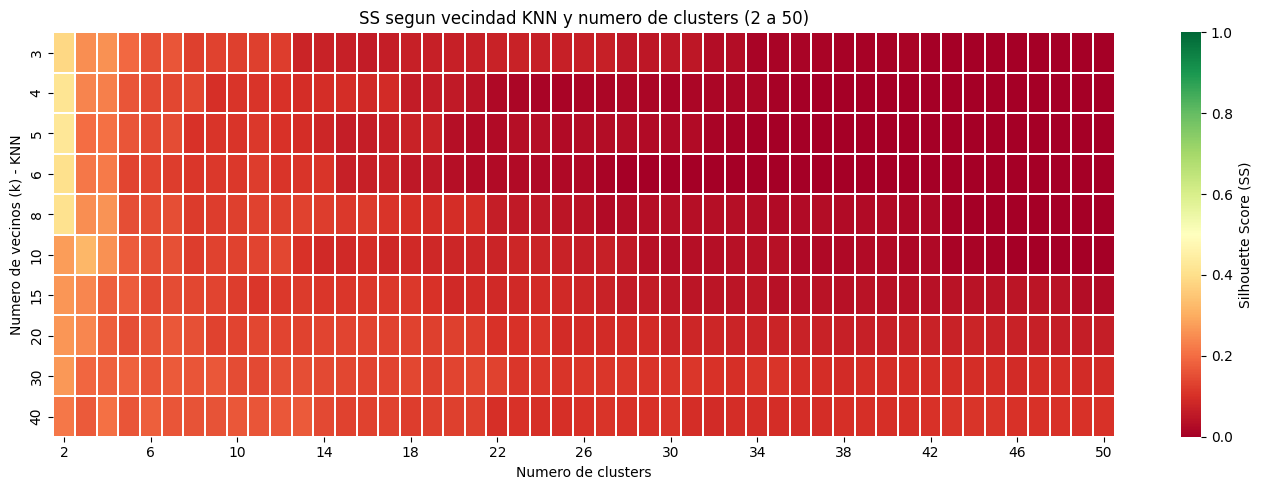

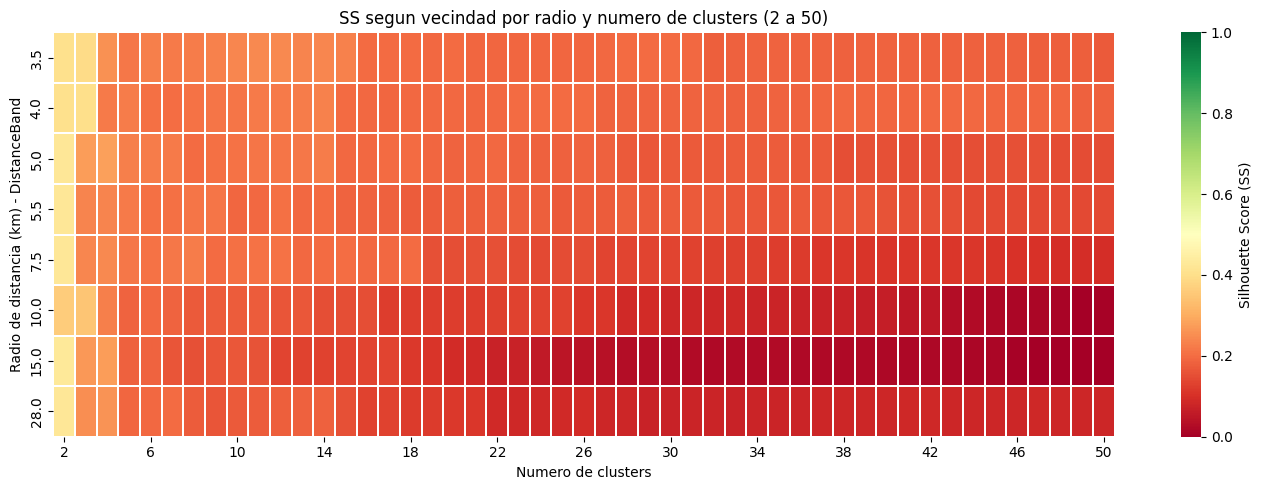

In [15]:
PALETA_SS = "RdYlGn"
TICKS_X_CLUSTERS = list(range(0, len(rango_n_clusters), 4))
ETIQUETAS_X_CLUSTERS = [rango_n_clusters[i] for i in TICKS_X_CLUSTERS]

fig_knn, ax_knn = plt.subplots(figsize=(14, 5))
sns.heatmap(matriz_ss_knn, xticklabels=False, yticklabels=vecinos_candidatos, cmap=PALETA_SS,
            vmin=0, vmax=1, annot=False, linewidths=0.3, cbar_kws={"label": "Silhouette Score (SS)"}, ax=ax_knn)
ax_knn.set_xticks([t + 0.5 for t in TICKS_X_CLUSTERS]); ax_knn.set_xticklabels(ETIQUETAS_X_CLUSTERS, rotation=0)
ax_knn.set_xlabel("Numero de clusters"); ax_knn.set_ylabel("Numero de vecinos (k) - KNN")
ax_knn.set_title("SS segun vecindad KNN y numero de clusters (2 a 50)")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "03_heatmap_ss_knn.png"), dpi=150)
plt.show()

fig_dist, ax_dist = plt.subplots(figsize=(14, 5))
sns.heatmap(matriz_ss_distancia, xticklabels=False, yticklabels=radios_candidatos_km, cmap=PALETA_SS,
            vmin=0, vmax=1, annot=False, linewidths=0.3, cbar_kws={"label": "Silhouette Score (SS)"}, ax=ax_dist)
ax_dist.set_xticks([t + 0.5 for t in TICKS_X_CLUSTERS]); ax_dist.set_xticklabels(ETIQUETAS_X_CLUSTERS, rotation=0)
ax_dist.set_xlabel("Numero de clusters"); ax_dist.set_ylabel("Radio de distancia (km) - DistanceBand")
ax_dist.set_title("SS segun vecindad por radio y numero de clusters (2 a 50)")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "04_heatmap_ss_distanceband.png"), dpi=150)
plt.show()


## [10] Mejor (vecindad, n_clusters) para cada modelo — búsqueda restringida a `n_clusters >= 4`

**Consolidado desde `06_mapas_clusters_n_mayor_3.py`:** en la versión anterior de este
notebook, la búsqueda del máximo en la grilla completa (esta sección) NO excluía k=2/k=3, a
diferencia de la sección de referencia (`K_ELEGIDO`). Aquí ambas búsquedas usan el mismo
criterio consistente: se descartan las columnas de la grilla con `n_clusters < 4` ANTES de
tomar el máximo, tanto para KNN como para DistanceBand.

**Ventajas / desventajas de optimizar sobre la grilla completa (restringida):**
- (+) Cada vecindad encuentra su mejor "resolución" (no se fuerza a comparar en un único
  `n_clusters` arbitrario).
- (-) Riesgo de comparaciones múltiples: entre más combinaciones se prueban, más probable
  es encontrar un máximo alto "por azar" en vez de una mejora genuina.


In [16]:
idx_col_validas = [j for j, n in enumerate(rango_n_clusters) if n >= N_CLUSTERS_MINIMO]


def mejor_combinacion_restringida(matriz, valores_vecindad, rango_n_clusters, columnas_validas):
    sub_matriz = matriz[:, columnas_validas]
    if np.all(np.isnan(sub_matriz)):
        return None, None, np.nan
    idx_plano = np.nanargmax(sub_matriz)
    i, j_sub = np.unravel_index(idx_plano, sub_matriz.shape)
    j = columnas_validas[j_sub]
    return valores_vecindad[i], rango_n_clusters[j], sub_matriz[i, j_sub]


mejor_k_knn, mejor_nclusters_knn, ss_max_knn = mejor_combinacion_restringida(
    matriz_ss_knn, vecinos_candidatos, rango_n_clusters, idx_col_validas)

mejor_radio_dist, mejor_nclusters_dist, ss_max_dist = mejor_combinacion_restringida(
    matriz_ss_distancia, radios_candidatos, rango_n_clusters, idx_col_validas)

print(f"[KNN, n_clusters>={N_CLUSTERS_MINIMO}] Mejor combinacion segun SS: "
      f"k={mejor_k_knn}, n_clusters={mejor_nclusters_knn} (SS={ss_max_knn:.3f})")
print(f"[DistanceBand, n_clusters>={N_CLUSTERS_MINIMO}] Mejor combinacion segun SS: "
      f"radio={mejor_radio_dist/1000:.1f} km, n_clusters={mejor_nclusters_dist} (SS={ss_max_dist:.3f})")

# Poligonos sin vecinos para el radio ganador (respuesta directa a la pregunta pedida)
w_check = DistanceBand.from_dataframe(gdf, threshold=mejor_radio_dist, binary=True)
print(f"\n>> Poligonos SIN vecinos con el radio ganador ({mejor_radio_dist/1000:.1f} km): "
      f"{len(w_check.islands)} de {len(gdf)} ({100*len(w_check.islands)/len(gdf):.1f}%)")
if len(w_check.islands) > 0:
    print("   ADVERTENCIA: el radio con mejor SS deja poligonos aislados; ver seccion [7] "
          "para el detalle completo por radio antes de confiar en este resultado sin mas.")


[KNN, n_clusters>=4] Mejor combinacion segun SS: k=8, n_clusters=4 (SS=0.260)
[DistanceBand, n_clusters>=4] Mejor combinacion segun SS: radio=5.0 km, n_clusters=4 (SS=0.280)

>> Poligonos SIN vecinos con el radio ganador (5.0 km): 132 de 491 (26.9%)
   ADVERTENCIA: el radio con mejor SS deja poligonos aislados; ver seccion [7] para el detalle completo por radio antes de confiar en este resultado sin mas.


C:\Users\MSI\anaconda3\Lib\site-packages\libpysal\weights\util.py:819: UserWarning: The weights matrix is not fully connected: 
 There are 208 disconnected components.
 There are 132 islands with ids: 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 30, 34, 39, 41, 42, 43, 53, 56, 58, 59, 60, 61, 64, 65, 66, 67, 68, 69, 70, 73, 77, 80, 85, 93, 106, 107, 108, 112, 114, 115, 139, 148, 151, 154, 155, 156, 157, 158, 160, 161, 163, 167, 170, 171, 173, 174, 182, 183, 184, 185, 188, 189, 195, 196, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 215, 217, 218, 219, 220, 221, 235, 236, 238, 240, 243, 252, 253, 254, 257, 260, 261, 263, 264, 266, 267, 312, 366, 382, 383, 384, 396, 397, 401, 403, 404, 407, 408, 409, 411, 412, 418, 424, 425, 426, 461, 462, 482, 483, 488.
  w = W(neighbors, weights, ids, **kwargs)
C:\Users\MSI\anaconda3\Lib\site-packages\libpysal\weights\distance.py:855: UserWarning: The weights matrix is not fully connected: 
 There are 208 di

In [17]:
w_ganador_knn = KNN.from_dataframe(gdf, k=mejor_k_knn)
conectividad_ganadora_knn = simetrizar(w_ganador_knn.sparse)
etiquetas_mejor_knn = AgglomerativeClustering(
    n_clusters=mejor_nclusters_knn, linkage="ward", connectivity=conectividad_ganadora_knn
).fit_predict(X)

w_ganador_dist = DistanceBand.from_dataframe(gdf, threshold=mejor_radio_dist, binary=True)
conectividad_ganadora_dist = simetrizar(w_ganador_dist.sparse)
etiquetas_mejor_dist = AgglomerativeClustering(
    n_clusters=mejor_nclusters_dist, linkage="ward", connectivity=conectividad_ganadora_dist
).fit_predict(X)

gdf["cluster_mejor_knn"] = etiquetas_mejor_knn
gdf["cluster_mejor_distancia"] = etiquetas_mejor_dist

if ss_max_knn >= ss_max_dist:
    etiquetas_finales = etiquetas_mejor_knn
    mejor_global_desc = f"KNN (k={mejor_k_knn}, n_clusters={mejor_nclusters_knn})"
    mejor_global_ss = ss_max_knn
else:
    etiquetas_finales = etiquetas_mejor_dist
    mejor_global_desc = f"DistanceBand (radio={mejor_radio_dist/1000:.1f} km, n_clusters={mejor_nclusters_dist})"
    mejor_global_ss = ss_max_dist

print(f">> Mejor configuracion global (entre KNN y DistanceBand): {mejor_global_desc}, Silhouette={mejor_global_ss:.3f}")
print(f">> Linea base sin restriccion espacial (K_ELEGIDO={K_ELEGIDO}): Silhouette={silhouette_base:.3f}")

gdf["cluster_espacial"] = etiquetas_finales


C:\Users\MSI\anaconda3\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
C:\Users\MSI\anaconda3\Lib\site-packages\libpysal\weights\util.py:819: UserWarning: The weights matrix is not fully connected: 
 There are 208 disconnected components.
 There are 132 islands with ids: 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 30, 34, 39, 41, 42, 43, 53, 56, 58, 59, 60, 61, 64, 65, 66, 67, 68, 69, 70, 73, 77, 80, 85, 93, 106, 107, 108, 112, 114, 115, 139, 148, 151, 154, 155, 156, 157, 158, 160, 161, 163, 167, 170, 171, 173, 174, 182, 183, 184, 

>> Mejor configuracion global (entre KNN y DistanceBand): DistanceBand (radio=5.0 km, n_clusters=4), Silhouette=0.280
>> Linea base sin restriccion espacial (K_ELEGIDO=7): Silhouette=0.211


## [11] Otros análisis pertinentes

**(a) Índice de Rand Ajustado (ARI):** compara la partición ganadora contra la partición
SIN restricción espacial para cuantificar qué tanto cambió realmente la tipología (1.0 =
partición idéntica, 0.0 = tan distinta como una asignación al azar).

**(b) Diagnóstico espacial simple:** ¿los altiplanos de un mismo cluster quedaron además
más cerca geográficamente entre sí que altiplanos de clusters distintos? Se compara la
distancia promedio entre centroides DENTRO de cada cluster contra la distancia promedio
ENTRE clusters — algo que el Silhouette (calculado en el espacio de atributos) no puede
decirnos por sí solo.


In [18]:
ari = adjusted_rand_score(etiquetas_base, etiquetas_finales)
print(f"Indice de Rand Ajustado (ganadora vs. sin restriccion espacial): {ari:.3f}")

matriz_distancias = squareform(pdist(coordenadas))
mismo_cluster = etiquetas_finales[:, None] == etiquetas_finales[None, :]
np.fill_diagonal(mismo_cluster, False)

dist_dentro = matriz_distancias[mismo_cluster].mean()
dist_entre = matriz_distancias[~mismo_cluster].mean()
print(f"Distancia promedio ENTRE CENTROIDES dentro del mismo cluster: {dist_dentro / 1000:,.1f} km")
print(f"Distancia promedio ENTRE CENTROIDES de clusters distintos:   {dist_entre / 1000:,.1f} km")
if dist_dentro < dist_entre:
    print("-> Los altiplanos del mismo tipo SI tienden a estar mas cerca entre si que los de tipos distintos.")
else:
    print("-> Los altiplanos del mismo tipo NO estan mas cerca entre si; el patron es principalmente morfometrico, no geografico.")


Indice de Rand Ajustado (ganadora vs. sin restriccion espacial): 0.326
Distancia promedio ENTRE CENTROIDES dentro del mismo cluster: 129.0 km
Distancia promedio ENTRE CENTROIDES de clusters distintos:   162.3 km
-> Los altiplanos del mismo tipo SI tienden a estar mas cerca entre si que los de tipos distintos.


## [12] Mapas: línea base, mejor KNN y mejor DistanceBand

Se mapean las TRES tipologías resultantes para poder comparar visualmente si la vecindad
geográfica cambia la distribución espacial de los tipos de altiplano.


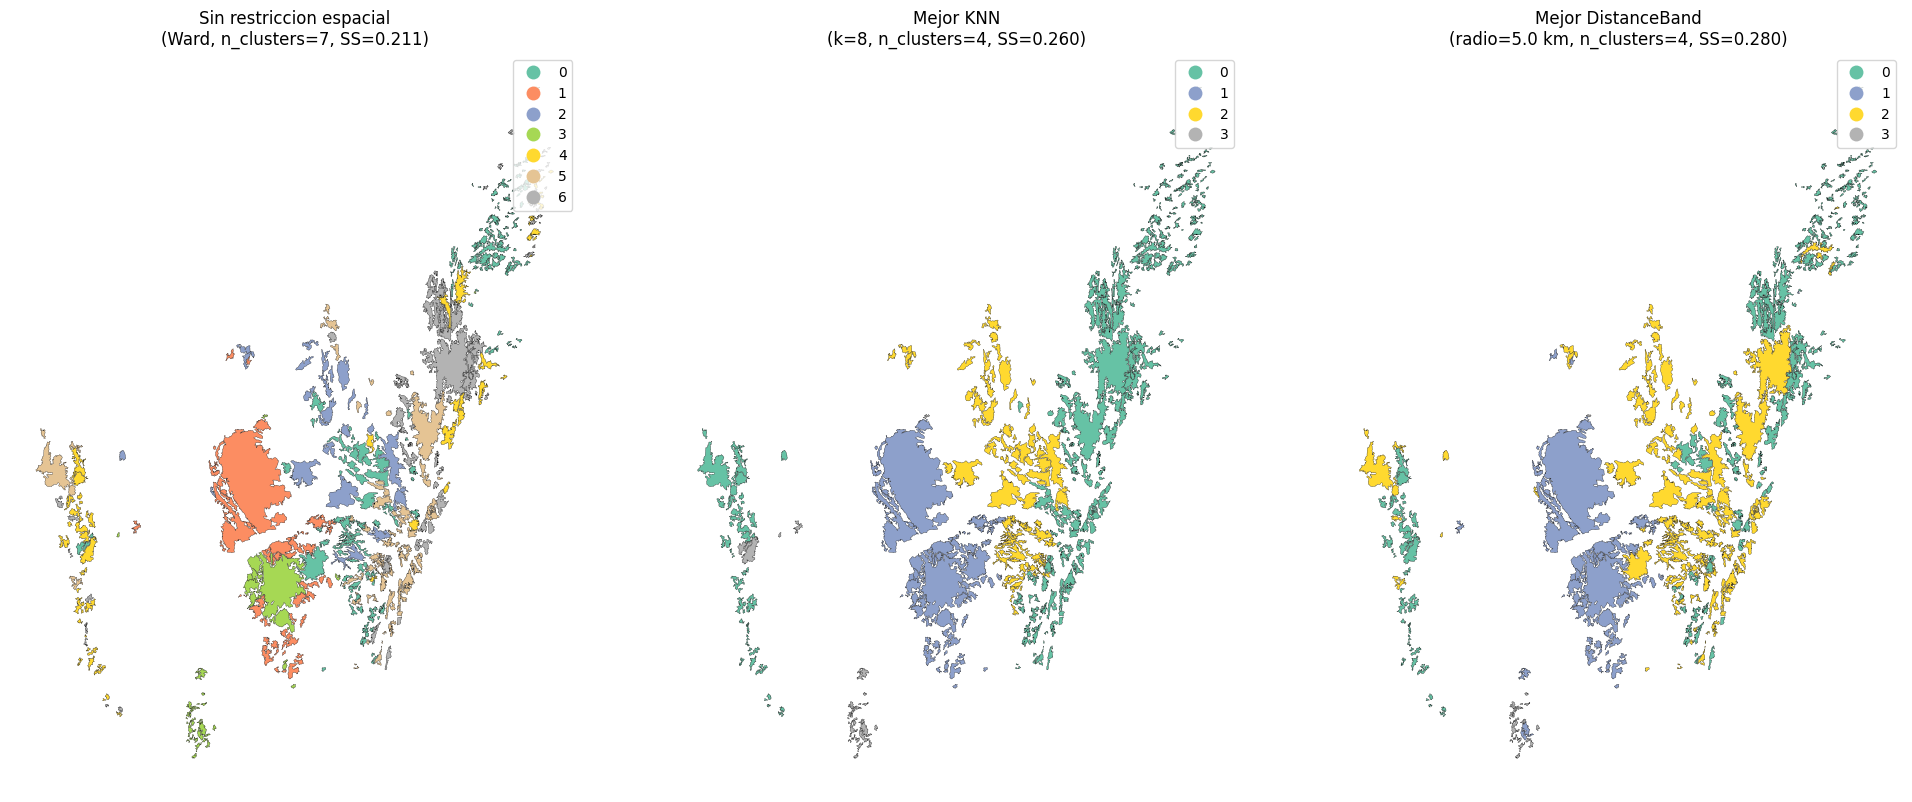

In [19]:
gdf["cluster_sin_restriccion"] = etiquetas_base

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8))

gdf.plot(column="cluster_sin_restriccion", categorical=True, legend=True, cmap="Set2",
         edgecolor="black", linewidth=0.2, ax=ax1)
ax1.set_title(f"Sin restriccion espacial\n(Ward, n_clusters={K_ELEGIDO}, SS={silhouette_base:.3f})")
ax1.set_axis_off()

gdf.plot(column="cluster_mejor_knn", categorical=True, legend=True, cmap="Set2",
         edgecolor="black", linewidth=0.2, ax=ax2)
ax2.set_title(f"Mejor KNN\n(k={mejor_k_knn}, n_clusters={mejor_nclusters_knn}, SS={ss_max_knn:.3f})")
ax2.set_axis_off()

gdf.plot(column="cluster_mejor_distancia", categorical=True, legend=True, cmap="Set2",
         edgecolor="black", linewidth=0.2, ax=ax3)
ax3.set_title(f"Mejor DistanceBand\n(radio={mejor_radio_dist/1000:.1f} km, n_clusters={mejor_nclusters_dist}, SS={ss_max_dist:.3f})")
ax3.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "07_mapa_comparacion_espacial.png"), dpi=150)
plt.show()


### [12b] Versión cartográfica del mapa comparativo (plantilla con hillshade/norte/escala)

Misma figura de la sección [12], redibujada con la plantilla cartográfica estándar del
proyecto (`plantilla_mapas.py`) en cada uno de los 3 paneles. Esta celda solo llama a las
capas ya calculadas (`gdf`) — no repite ningún cálculo del análisis.

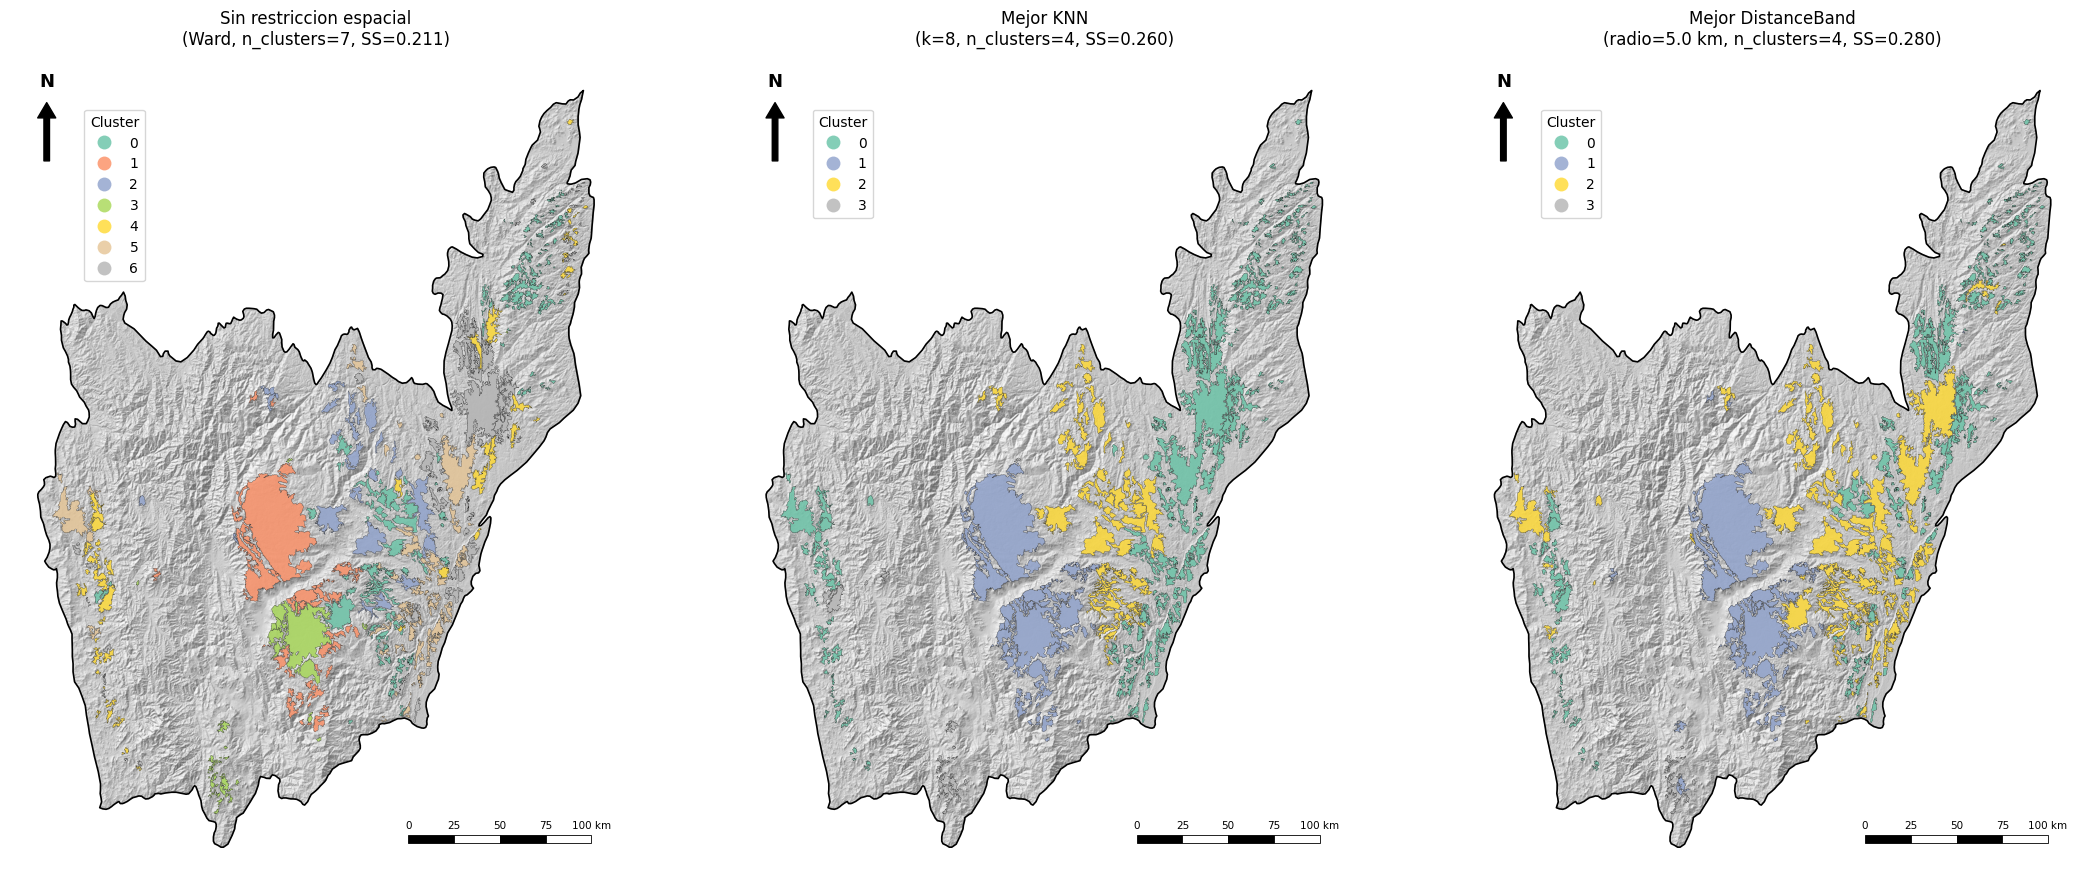

In [20]:
from plantilla_mapas import aplicar_plantilla_mapa, posicionar_leyenda, CARPETA_IMAGENES

CARPETA_IMAGENES_NB = os.path.join(CARPETA_IMAGENES, "02_clustering_espacial_altiplanos_v2")
os.makedirs(CARPETA_IMAGENES_NB, exist_ok=True)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 9))

columnas_paneles = ["cluster_sin_restriccion", "cluster_mejor_knn", "cluster_mejor_distancia"]
titulos_paneles = [
    f"Sin restriccion espacial\n(Ward, n_clusters={K_ELEGIDO}, SS={silhouette_base:.3f})",
    f"Mejor KNN\n(k={mejor_k_knn}, n_clusters={mejor_nclusters_knn}, SS={ss_max_knn:.3f})",
    f"Mejor DistanceBand\n(radio={mejor_radio_dist/1000:.1f} km, n_clusters={mejor_nclusters_dist}, SS={ss_max_dist:.3f})",
]

for ax, columna, titulo in zip([ax1, ax2, ax3], columnas_paneles, titulos_paneles):
    ancla = aplicar_plantilla_mapa(ax)
    gdf.plot(column=columna, categorical=True, legend=True, cmap="Set2", alpha=0.8,
              edgecolor="black", linewidth=0.2, ax=ax, zorder=5,
              legend_kwds=posicionar_leyenda(ax, ancla, titulo="Cluster"))
    ax.set_title(titulo)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "07_mapa_comparacion_espacial.png"), dpi=150)
plt.show()


## [13] Exportar resultados

Se usa el sufijo `_v2` para no sobrescribir `Resultados\altiplanos_clustering_espacial.gpkg`
(capa de la versión anterior).


In [21]:
ruta_salida = os.path.join(CARPETA_RESULTADOS, "altiplanos_clustering_espacial_v2.gpkg")
gdf.to_file(ruta_salida, driver="GPKG")
print(f"Resultado guardado en: {ruta_salida}")


Resultado guardado en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\altiplanos_clustering_espacial_v2.gpkg


## Conclusiones

- **Vecinos por distancia:** la sección [7] deja explícito, radio por radio, cuántos de
  los 491 altiplanos quedan sin ningún vecino en `DistanceBand`; con radios pequeños esta
  cifra puede ser sustancial, lo cual advierte sobre la confiabilidad de un Silhouette alto
  logrado con un radio así (aunque KNN, por construcción, nunca deja polígonos aislados).
- Si la línea base (sin restricción espacial) tiene el Silhouette más alto de las tres
  configuraciones, significa que para este conjunto de datos la cercanía geográfica entre
  altiplanos no ayuda a formar grupos morfométricamente más compactos — un resultado
  legítimo y coherente con que los altiplanos sean "parches" aislados, no un fenómeno
  regional continuo.
- **Siguiente paso natural:** `04_autocorrelacion_espacial_v2.ipynb` retoma esta capa
  exportada para calcular el Índice de Moran y LISA sobre la morfometría de los 491
  altiplanos.
